In [ ]:
!pip install pennylane

In [89]:
import pennylane as qml
import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [167]:
data = load_breast_cancer()

X = data.data
y = data.target

In [168]:
np.unique(y, return_counts=True)

(array([0, 1]), array([212, 357]))

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [170]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [171]:
pca = PCA(n_components=4)

X_train_encoded = pca.fit_transform(X_train_scaled)
X_test_encoded = pca.transform(X_test_scaled)

In [172]:
max_abs = np.max(np.abs(X_train_encoded))

X_train_encoded = X_train_encoded / max_abs * np.pi
X_test_encoded = X_test_encoded / max_abs * np.pi

In [173]:
X_train_benign = X_train_encoded[y_train == 1]

In [97]:
X_train_benign.shape

(285, 3)

In [174]:
X_train_benign = torch.tensor(X_train_benign,dtype=torch.float64)

X_test_tensor = torch.tensor(X_test_encoded,dtype=torch.float64)

In [175]:
n_qubits = 4
n_layers = 12

latent_wires = [0, 1]
trash_wires = [2,3]

dev = qml.device("default.qubit",wires=n_qubits)

In [176]:
@qml.qnode(dev, interface="torch")
def qae_circuit(inputs, weights):

    qml.AngleEmbedding(
    features=inputs,
    wires=range(n_qubits),
    rotation="Y"
)

    #Variational Ansatz
    qml.StronglyEntanglingLayers(
        weights,
        wires=range(n_qubits)
    )

    # Probabilities of trash states:
    return qml.probs(wires=trash_wires)

In [177]:
weight_shape = (n_layers, n_qubits, 3)

weights = torch.nn.Parameter(
    0.01 * torch.randn(weight_shape,dtype=torch.float64)
)

In [ ]:
weights.shape

torch.Size([12, 4, 3])

In [178]:
def trash_fidelity(x, weights):

    probs = qae_circuit(
        x,
        weights
    )

    # probs[0] = P(q3 q4 = 00)

    return probs[0]

In [179]:
def qae_loss(batch, weights):

    fidelities = []

    for x in batch:

        fidelity = trash_fidelity(
            x,
            weights
        )

        fidelities.append(
            fidelity
        )

    mean_fidelity = torch.stack(
        fidelities
    ).mean()

    return 1.0 - mean_fidelity

In [180]:
optimizer = torch.optim.Adam([weights],lr=0.005)

In [181]:
epochs = 60
batch_size = 16

for epoch in range(epochs):

    permutation = torch.randperm(
        len(X_train_benign)
    )

    epoch_loss = 0.0
    n_batches = 0

    for i in range(
        0,
        len(X_train_benign),
        batch_size
    ):

        indices = permutation[
            i:i + batch_size
        ]

        batch = X_train_benign[
            indices
        ]

        optimizer.zero_grad()

        loss = qae_loss(
            batch,
            weights
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        n_batches += 1

    avg_loss = (
        epoch_loss / n_batches
    )

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 01 | Loss: 0.163379
Epoch 02 | Loss: 0.125696
Epoch 03 | Loss: 0.106916
Epoch 04 | Loss: 0.092844
Epoch 05 | Loss: 0.078034
Epoch 06 | Loss: 0.064856
Epoch 07 | Loss: 0.053052
Epoch 08 | Loss: 0.043690
Epoch 09 | Loss: 0.035278
Epoch 10 | Loss: 0.031354
Epoch 11 | Loss: 0.029105
Epoch 12 | Loss: 0.027727
Epoch 13 | Loss: 0.026871
Epoch 14 | Loss: 0.026367
Epoch 15 | Loss: 0.025772
Epoch 16 | Loss: 0.025436
Epoch 17 | Loss: 0.025329
Epoch 18 | Loss: 0.025076
Epoch 19 | Loss: 0.024963
Epoch 20 | Loss: 0.024750
Epoch 21 | Loss: 0.024643
Epoch 22 | Loss: 0.024408
Epoch 23 | Loss: 0.024669
Epoch 24 | Loss: 0.024605
Epoch 25 | Loss: 0.024379
Epoch 26 | Loss: 0.024178
Epoch 27 | Loss: 0.024322
Epoch 28 | Loss: 0.024166
Epoch 29 | Loss: 0.024279
Epoch 30 | Loss: 0.024026
Epoch 31 | Loss: 0.024169
Epoch 32 | Loss: 0.024769
Epoch 33 | Loss: 0.023850
Epoch 34 | Loss: 0.023948
Epoch 35 | Loss: 0.023770
Epoch 36 | Loss: 0.023706
Epoch 37 | Loss: 0.023720
Epoch 38 | Loss: 0.023823
Epoch 39 | L

In [182]:
def anomaly_score(x, weights):

    fidelity = trash_fidelity(
        x,
        weights
    )

    return 1.0 - fidelity

In [183]:
test_scores = []

with torch.no_grad():

    for x in X_test_tensor:

        score = anomaly_score(
            x,
            weights
        )

        test_scores.append(
            score.item()
        )

test_scores = np.array(
    test_scores
)


In [184]:
benign_scores = test_scores[
    y_test == 1
]

malignant_scores = test_scores[
    y_test == 0
]

print()

print(
    "Mean benign anomaly score:",
    benign_scores.mean()
)

print(
    "Mean malignant anomaly score:",
    malignant_scores.mean()
)


Mean benign anomaly score: 0.022598135990753842
Mean malignant anomaly score: 0.11732843183649672


In [185]:
train_benign_scores = []

with torch.no_grad():
    for x in X_train_benign:
        score = anomaly_score(x, weights)
        train_benign_scores.append(score.item())

print("Train benign:", np.mean(train_benign_scores))
print("Test benign:", benign_scores.mean())
print("Test malignant:", malignant_scores.mean())

Train benign: 0.023483157051795992
Test benign: 0.022598135990753842
Test malignant: 0.11732843183649672


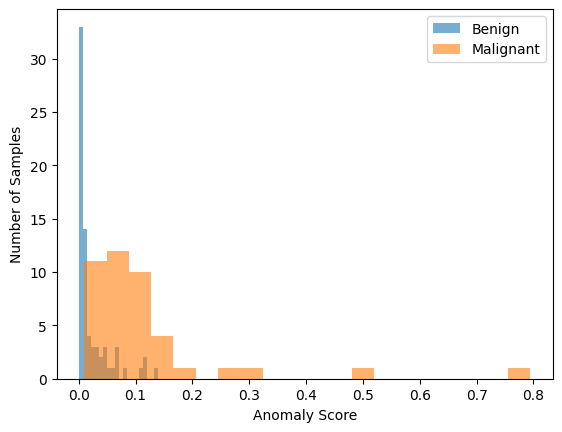

In [186]:
import matplotlib.pyplot as plt

plt.hist(
    benign_scores,
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.hist(
    malignant_scores,
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Samples")
plt.legend()

plt.show()

In [187]:
from sklearn.metrics import roc_auc_score

# malignant = 1 for anomaly detection evaluation
y_anomaly = (y_test == 0).astype(int)

auc = roc_auc_score(
    y_anomaly,
    test_scores
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8918650793650793


In [188]:
from sklearn.metrics import classification_report

threshold = 0.0055


y_pred = np.where(test_scores > threshold,0, 1)

print(classification_report(y_test,y_pred,target_names=["Malignant", "Benign"]))

              precision    recall  f1-score   support

   Malignant       0.46      1.00      0.63        42
      Benign       1.00      0.32      0.48        72

    accuracy                           0.57       114
   macro avg       0.73      0.66      0.56       114
weighted avg       0.80      0.57      0.54       114



In [128]:
from sklearn.metrics import classification_report, accuracy_score

for threshold in [0.0059,0.0062,0.0067]:

    y_pred = np.where(
        test_scores > threshold,
        0,
        1
    )

    print("\nThreshold:", threshold)
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Malignant", "Benign"]
        )
    )


Threshold: 0.0059
Accuracy: 0.8596491228070176
              precision    recall  f1-score   support

   Malignant       0.74      0.95      0.83        42
      Benign       0.97      0.81      0.88        72

    accuracy                           0.86       114
   macro avg       0.85      0.88      0.86       114
weighted avg       0.88      0.86      0.86       114


Threshold: 0.0062
Accuracy: 0.8859649122807017
              precision    recall  f1-score   support

   Malignant       0.78      0.95      0.86        42
      Benign       0.97      0.85      0.90        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.88       114
weighted avg       0.90      0.89      0.89       114


Threshold: 0.0067
Accuracy: 0.8859649122807017
              precision    recall  f1-score   support

   Malignant       0.80      0.93      0.86        42
      Benign       0.95      0.86      0.91        72

    accuracy                          